### Hybrid Stacking (ARIMA + Random Forest)

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
import warnings
warnings.filterwarnings('ignore')


### Load Predictions

In [26]:
arima_pred = pd.read_csv('../reports/predictions/arima_predictions.csv')
arima_pred['Date'] = pd.to_datetime(arima_pred['Date'])
print(f"ARIMA predictions loaded: {len(arima_pred)} samples")

# Load RF predictions
rf_pred = pd.read_csv('../reports/predictions/rf_regressor_temp_predictions_report.csv')
rf_pred['Date'] = pd.to_datetime(rf_pred['Date'])
print(f"Random Forest predictions loaded: {len(rf_pred)} samples")

# Align datasets (they might have different lengths due to feature engineering)
merged = pd.merge(arima_pred, rf_pred, on='Date', suffixes=('_arima', '_rf'))
print(f"\nPredictions aligned: {len(merged)} samples")
print("\n🔍 DEBUGGING - Columns in merged dataframe:")
print(merged.columns.tolist())
print("\n🔍 First few rows:")
print(merged.head())
print(f"Date range: {merged['Date'].min().date()} to {merged['Date'].max().date()}")

# Extract values - use the actual column names from the merged dataframe
dates = merged['Date']
actual = merged['Actual']  # No suffix was applied since column only exists in one df
arima_predictions = merged['ARIMA_Prediction']
rf_predictions = merged['Predicted_Temperature']  # This is the RF prediction column

ARIMA predictions loaded: 2071 samples
Random Forest predictions loaded: 2071 samples

Predictions aligned: 2071 samples

🔍 DEBUGGING - Columns in merged dataframe:
['Date', 'Actual', 'ARIMA_Prediction', 'Error', 'Absolute_Error', 'True_Temperature', 'Predicted_Temperature', 'Prediction_Error']

🔍 First few rows:
        Date  Actual  ARIMA_Prediction     Error  Absolute_Error  \
0 2018-01-25    65.5         65.286572  0.213428        0.213428   
1 2018-01-26    67.1         65.286572  1.813428        1.813428   
2 2018-01-27    68.2         65.286572  2.913428        2.913428   
3 2018-01-28    70.0         65.286572  4.713428        4.713428   
4 2018-01-29    67.4         65.286572  2.113428        2.113428   

   True_Temperature  Predicted_Temperature  Prediction_Error  
0              65.5              65.221136          0.278864  
1              67.1              67.064191          0.035809  
2              68.2              68.499797         -0.299797  
3              70.0     

### Evaluate Individual Models

In [27]:
# ARIMA metrics
arima_mae = mean_absolute_error(actual, arima_predictions)
arima_rmse = np.sqrt(mean_squared_error(actual, arima_predictions))
arima_r2 = r2_score(actual, arima_predictions)

print("\nARIMA Model:")
print(f"MAE:  {arima_mae:.2f}°F")
print(f"RMSE: {arima_rmse:.2f}°F")
print(f"R²:   {arima_r2:.3f}")

# RF metrics
rf_mae = mean_absolute_error(actual, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(actual, rf_predictions))
rf_r2 = r2_score(actual, rf_predictions)

print("\nRandom Forest Model:")
print(f"MAE:  {rf_mae:.2f}°F")
print(f"RMSE: {rf_rmse:.2f}°F")
print(f"R²:   {rf_r2:.3f}")



ARIMA Model:
MAE:  7.20°F
RMSE: 10.18°F
R²:   0.554

Random Forest Model:
MAE:  0.52°F
RMSE: 0.88°F
R²:   0.997


### Simple Averaging

In [28]:
print("\nCombining predictions with equal weights...")
simple_avg_pred = (arima_predictions + rf_predictions) / 2

avg_mae = mean_absolute_error(actual, simple_avg_pred)
avg_rmse = np.sqrt(mean_squared_error(actual, simple_avg_pred))
avg_r2 = r2_score(actual, simple_avg_pred)

print("\nSimple Average (50% ARIMA + 50% RF):")
print(f"MAE:  {avg_mae:.2f}°F")
print(f"RMSE: {avg_rmse:.2f}°F")
print(f"R²:   {avg_r2:.3f}")

improvement_avg = ((min(arima_mae, rf_mae) - avg_mae) / min(arima_mae, rf_mae)) * 100
if improvement_avg > 0:
    print(f"Improvement: {improvement_avg:.1f}% over best individual model")
else:
    print(f"Worse than individual models")


Combining predictions with equal weights...

Simple Average (50% ARIMA + 50% RF):
MAE:  3.73°F
RMSE: 5.26°F
R²:   0.881
Worse than individual models


### Meta-Learner Stacking

In [29]:
# For meta-learning, we need a validation split
# Use first 80% of test data for training meta-learner, last 20% for final eval
meta_split = int(len(merged) * 0.8)

# Meta-training data
meta_train_features = np.column_stack([
    arima_predictions[:meta_split],
    rf_predictions[:meta_split]
])
meta_train_targets = actual[:meta_split]

# Meta-test data  
meta_test_features = np.column_stack([
    arima_predictions[meta_split:],
    rf_predictions[meta_split:]
])
meta_test_targets = actual[meta_split:]

# Train meta-learner
meta_learner = LinearRegression()
meta_learner.fit(meta_train_features, meta_train_targets)

print("Meta-learner trained!")
print(f"\nLearned Weights:")
print(f"ARIMA weight: {meta_learner.coef_[0]:.3f}")
print(f"RF weight:    {meta_learner.coef_[1]:.3f}")
print(f"Intercept:    {meta_learner.intercept_:.3f}")

# Interpretation
total_weight = abs(meta_learner.coef_[0]) + abs(meta_learner.coef_[1])
arima_pct = abs(meta_learner.coef_[0]) / total_weight * 100
rf_pct = abs(meta_learner.coef_[1]) / total_weight * 100

print(f"\nRelative Importance:")
print(f"ARIMA: {arima_pct:.1f}%")
print(f"RF:    {rf_pct:.1f}%")

if arima_pct > 60:
    print("ARIMA is more influential (better at capturing temporal patterns)")
elif rf_pct > 60:
    print("RF is more influential (better at capturing feature patterns)")
else:
    print("Balanced contribution from both models")

# Predictions using meta-learner
meta_all_features = np.column_stack([arima_predictions, rf_predictions])
meta_predictions = meta_learner.predict(meta_all_features)

meta_mae = mean_absolute_error(actual, meta_predictions)
meta_rmse = np.sqrt(mean_squared_error(actual, meta_predictions))
meta_r2 = r2_score(actual, meta_predictions)

print(f"\nMeta-Learner Stacking:")
print(f"MAE:  {meta_mae:.2f}°F")
print(f"RMSE: {meta_rmse:.2f}°F")
print(f"R²:   {meta_r2:.3f}")

improvement_meta = ((min(arima_mae, rf_mae) - meta_mae) / min(arima_mae, rf_mae)) * 100
if improvement_meta > 0:
    print(f"Improvement: {improvement_meta:.1f}% over best individual model")

Meta-learner trained!

Learned Weights:
ARIMA weight: -0.018
RF weight:    1.026
Intercept:    -0.653

Relative Importance:
ARIMA: 1.7%
RF:    98.3%
RF is more influential (better at capturing feature patterns)

Meta-Learner Stacking:
MAE:  0.51°F
RMSE: 0.84°F
R²:   0.997
Improvement: 2.9% over best individual model


### Model Comparison

In [30]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Model': [
        'ARIMA Only',
        'Random Forest Only', 
        'Simple Average',
        'Meta-Learner Stacking'
    ],
    'MAE (°F)': [arima_mae, rf_mae, avg_mae, meta_mae],
    'RMSE (°F)': [arima_rmse, rf_rmse, avg_rmse, meta_rmse],
    'R²': [arima_r2, rf_r2, avg_r2, meta_r2]
})

print("\n" + comparison_df.to_string(index=False))

# Find best model
best_idx = comparison_df['MAE (°F)'].idxmin()
best_model = comparison_df.loc[best_idx, 'Model']
best_mae = comparison_df.loc[best_idx, 'MAE (°F)']

print(f"\nBest Model: {best_model}")
print(f"MAE: {best_mae:.2f}°F")

# Calculate improvements
print(f"\nImprovement vs ARIMA:")
print(f"RF: {((arima_mae - rf_mae) / arima_mae * 100):.1f}%")
print(f"Simple Avg: {((arima_mae - avg_mae) / arima_mae * 100):.1f}%")
print(f"Meta-Learner: {((arima_mae - meta_mae) / arima_mae * 100):.1f}%")

# Use meta-learner as final hybrid model
hybrid_predictions = meta_predictions


                Model  MAE (°F)  RMSE (°F)       R²
           ARIMA Only  7.197279  10.176075 0.553987
   Random Forest Only  0.521040   0.882545 0.996645
       Simple Average  3.727601   5.260987 0.880788
Meta-Learner Stacking  0.505722   0.840116 0.996960

Best Model: Meta-Learner Stacking
MAE: 0.51°F

Improvement vs ARIMA:
RF: 92.8%
Simple Avg: 48.2%
Meta-Learner: 93.0%


### Visualization

Saved: hybrid_comparison.png


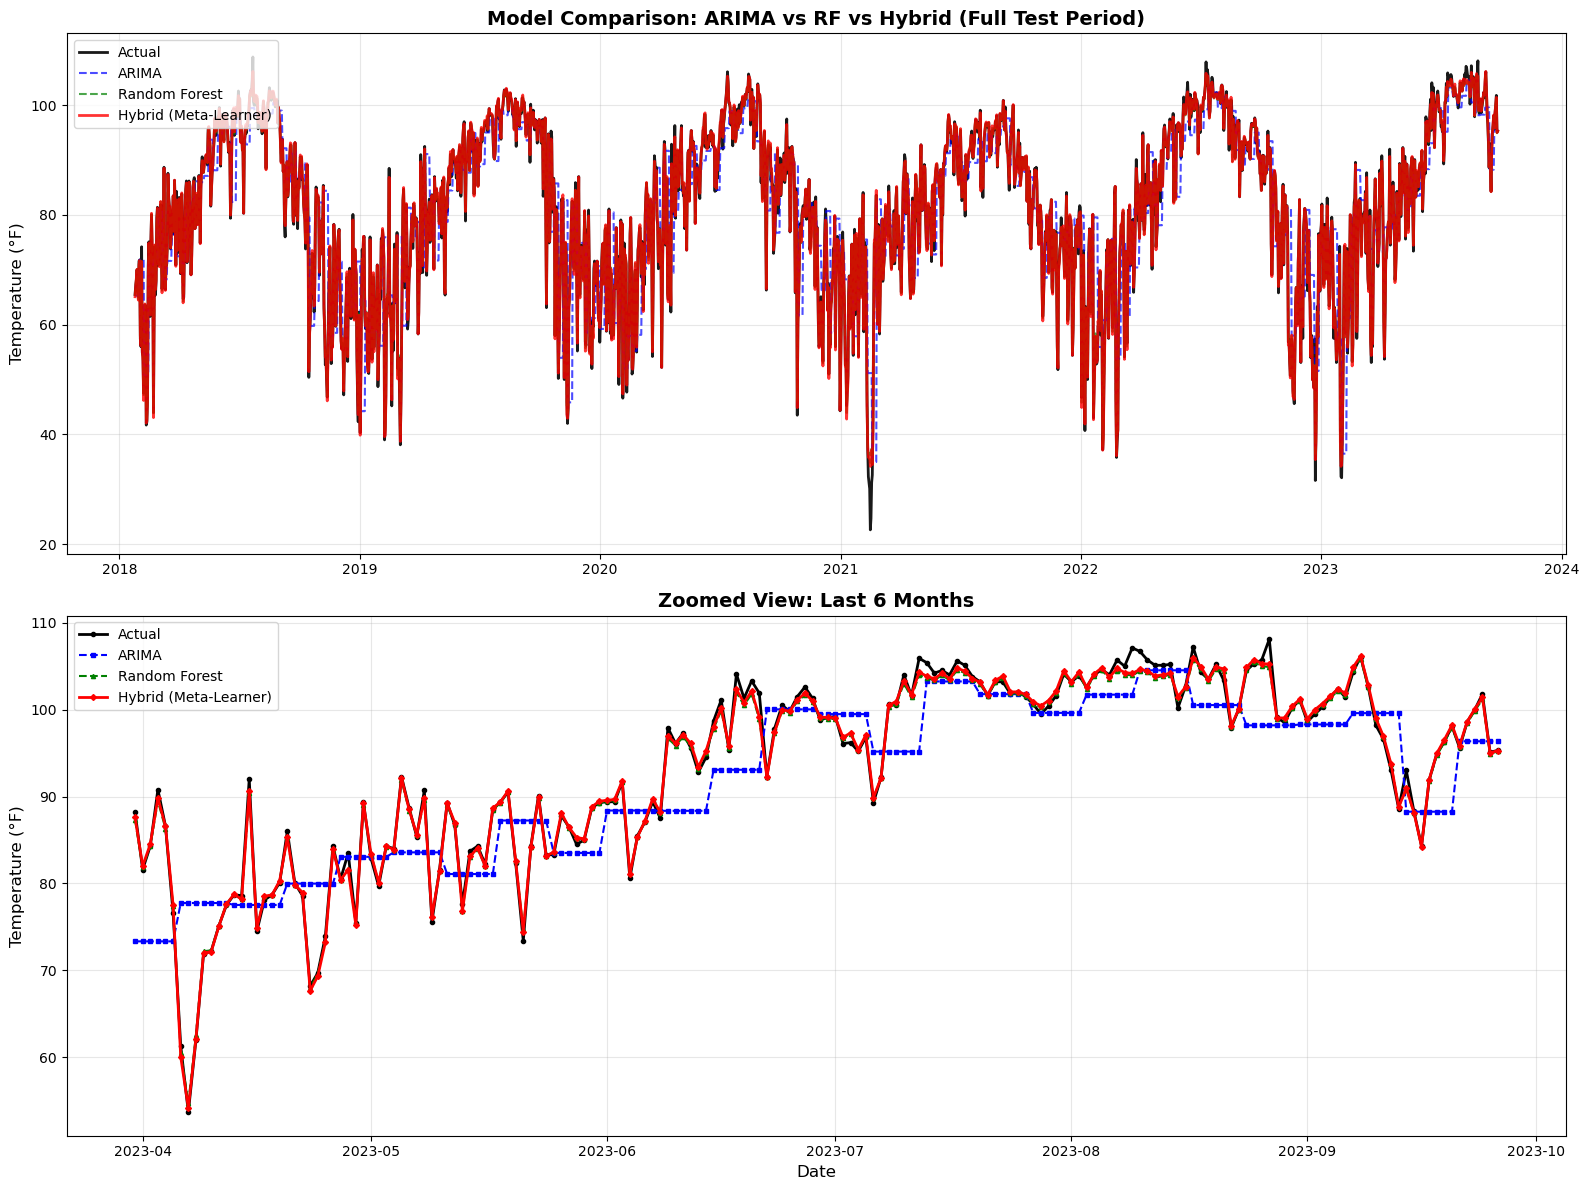

Saved: model_metrics_comparison.png


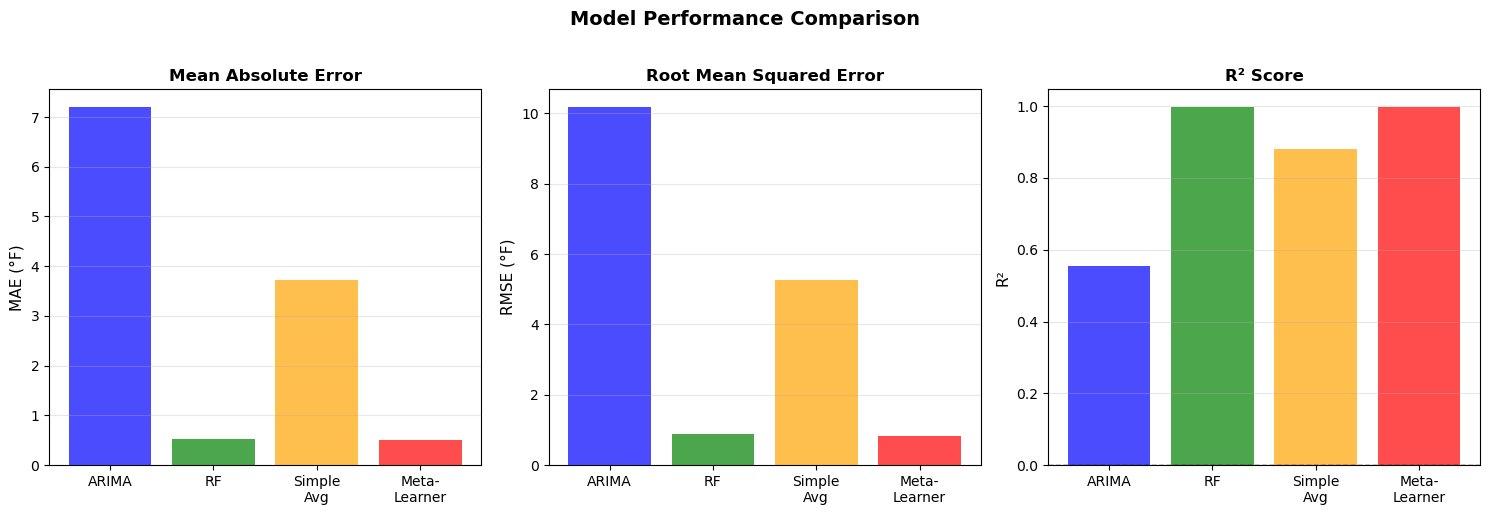

Saved: error_distributions.png


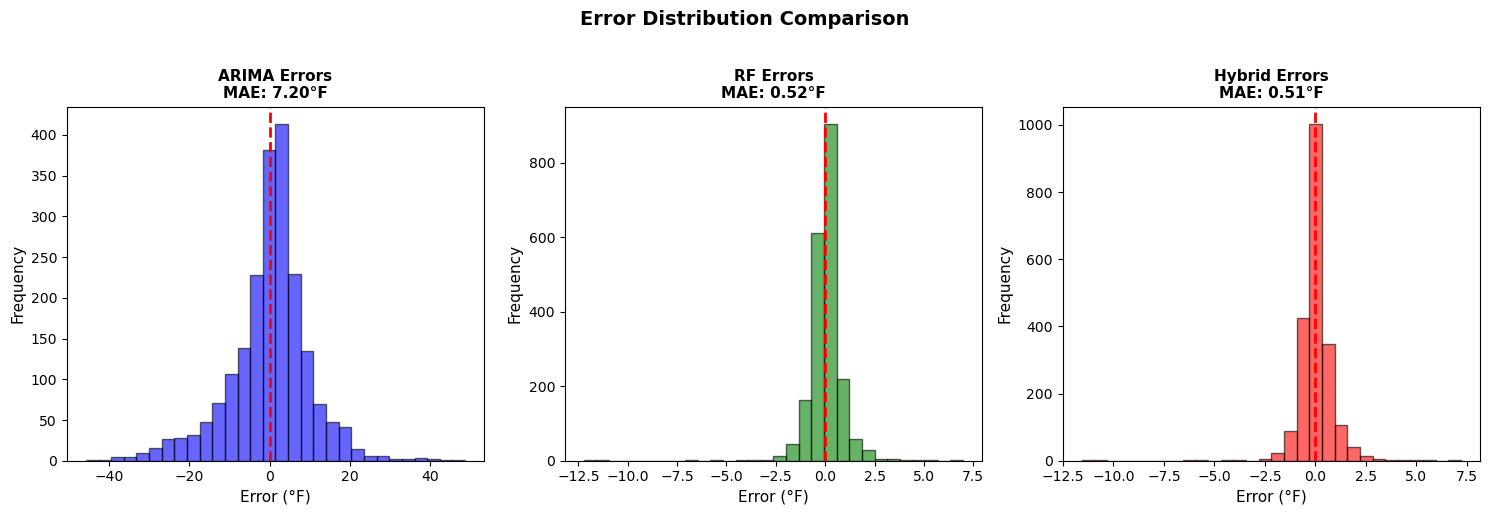

In [31]:
# Plot 1: All model predictions comparison
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Full period
axes[0].plot(dates, actual, label='Actual', color='black', linewidth=2, alpha=0.9)
axes[0].plot(dates, arima_predictions, label='ARIMA', color='blue', linestyle='--', linewidth=1.5, alpha=0.7)
axes[0].plot(dates, rf_predictions, label='Random Forest', color='green', linestyle='--', linewidth=1.5, alpha=0.7)
axes[0].plot(dates, hybrid_predictions, label='Hybrid (Meta-Learner)', color='red', linestyle='-', linewidth=2, alpha=0.8)

axes[0].set_ylabel('Temperature (°F)', fontsize=12)
axes[0].set_title('Model Comparison: ARIMA vs RF vs Hybrid (Full Test Period)', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Zoomed view (last 180 days or all if less)
zoom_n = min(180, len(dates))
zoom_dates = dates.iloc[-zoom_n:]
zoom_actual = actual.iloc[-zoom_n:]
zoom_arima = arima_predictions.iloc[-zoom_n:]
zoom_rf = rf_predictions.iloc[-zoom_n:]
zoom_hybrid = hybrid_predictions[-zoom_n:]

axes[1].plot(zoom_dates, zoom_actual, label='Actual', color='black', linewidth=2, marker='o', markersize=3)
axes[1].plot(zoom_dates, zoom_arima, label='ARIMA', color='blue', linestyle='--', linewidth=1.5, marker='s', markersize=3)
axes[1].plot(zoom_dates, zoom_rf, label='Random Forest', color='green', linestyle='--', linewidth=1.5, marker='^', markersize=3)
axes[1].plot(zoom_dates, zoom_hybrid, label='Hybrid (Meta-Learner)', color='red', linestyle='-', linewidth=2, marker='D', markersize=3)

axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Temperature (°F)', fontsize=12)
axes[1].set_title('Zoomed View: Last 6 Months', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/hybrid_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: hybrid_comparison.png")
plt.show()

# Plot 2: Model performance comparison (bar chart)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['ARIMA', 'RF', 'Simple\nAvg', 'Meta-\nLearner']
mae_values = [arima_mae, rf_mae, avg_mae, meta_mae]
rmse_values = [arima_rmse, rf_rmse, avg_rmse, meta_rmse]
r2_values = [arima_r2, rf_r2, avg_r2, meta_r2]

colors = ['blue', 'green', 'orange', 'red']

axes[0].bar(models, mae_values, color=colors, alpha=0.7)
axes[0].set_ylabel('MAE (°F)', fontsize=11)
axes[0].set_title('Mean Absolute Error', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(models, rmse_values, color=colors, alpha=0.7)
axes[1].set_ylabel('RMSE (°F)', fontsize=11)
axes[1].set_title('Root Mean Squared Error', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(models, r2_values, color=colors, alpha=0.7)
axes[2].set_ylabel('R²', fontsize=11)
axes[2].set_title('R² Score', fontsize=12, fontweight='bold')
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/model_metrics_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: model_metrics_comparison.png")
plt.show()

# Plot 3: Error analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Error distributions
arima_errors = actual - arima_predictions
rf_errors = actual - rf_predictions
hybrid_errors = actual - hybrid_predictions

axes[0].hist(arima_errors, bins=30, color='blue', alpha=0.6, edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Error (°F)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title(f'ARIMA Errors\nMAE: {arima_mae:.2f}°F', fontsize=11, fontweight='bold')

axes[1].hist(rf_errors, bins=30, color='green', alpha=0.6, edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Error (°F)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title(f'RF Errors\nMAE: {rf_mae:.2f}°F', fontsize=11, fontweight='bold')

axes[2].hist(hybrid_errors, bins=30, color='red', alpha=0.6, edgecolor='black')
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('Error (°F)', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].set_title(f'Hybrid Errors\nMAE: {meta_mae:.2f}°F', fontsize=11, fontweight='bold')

plt.suptitle('Error Distribution Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/error_distributions.png', dpi=300, bbox_inches='tight')
print("Saved: error_distributions.png")
plt.show()

### Save Hybrid Models and Predictions

In [32]:
# Save meta-learner model
meta_model_path = '../models/meta_learner.pkl'
with open(meta_model_path, 'wb') as f:
    pickle.dump(meta_learner, f)
print(f"Meta-learner saved: {meta_model_path}")

# Save hybrid predictions
hybrid_df = pd.DataFrame({
    'Date': dates,
    'Actual': actual,
    'ARIMA_Prediction': arima_predictions,
    'RF_Prediction': rf_predictions,
    'Hybrid_Prediction': hybrid_predictions,
    'Hybrid_Error': hybrid_errors,
    'Hybrid_Absolute_Error': np.abs(hybrid_errors)
})

hybrid_pred_path = '../reports/predictions/hybrid_predictions.csv'
hybrid_df.to_csv(hybrid_pred_path, index=False)
print(f"Hybrid predictions saved: {hybrid_pred_path}")

# Save comparison metrics
comparison_df.to_csv('../reports/predictions/model_comparison_metrics.csv', index=False)
print(f"Comparison metrics saved")

Meta-learner saved: ../models/meta_learner.pkl
Hybrid predictions saved: ../reports/predictions/hybrid_predictions.csv
Comparison metrics saved


### Summary

In [33]:
print(f"Final Hybrid Model (Meta-Learner):")
print(f"ARIMA weight: {meta_learner.coef_[0]:.3f} ({arima_pct:.1f}%)")
print(f"RF weight:    {meta_learner.coef_[1]:.3f} ({rf_pct:.1f}%)")

print(f"\nFinal Performance:")
print(f"MAE:  {meta_mae:.2f}°F")
print(f"RMSE: {meta_rmse:.2f}°F")
print(f"R²:   {meta_r2:.3f}")

print(f"\nImprovement over best individual model:")
best_individual_mae = min(arima_mae, rf_mae)
improvement_pct = ((best_individual_mae - meta_mae) / best_individual_mae) * 100
print(f"{improvement_pct:.1f}% reduction in MAE")

Final Hybrid Model (Meta-Learner):
ARIMA weight: -0.018 (1.7%)
RF weight:    1.026 (98.3%)

Final Performance:
MAE:  0.51°F
RMSE: 0.84°F
R²:   0.997

Improvement over best individual model:
2.9% reduction in MAE
